In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
!kaggle datasets download -d olistbr/brazilian-ecommerce

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
100% 42.6M/42.6M [00:00<00:00, 78.8MB/s]



In [4]:
!unzip brazilian-ecommerce.zip

Archive:  brazilian-ecommerce.zip
  inflating: olist_customers_dataset.csv  
  inflating: olist_geolocation_dataset.csv  
  inflating: olist_order_items_dataset.csv  
  inflating: olist_order_payments_dataset.csv  
  inflating: olist_order_reviews_dataset.csv  
  inflating: olist_orders_dataset.csv  
  inflating: olist_products_dataset.csv  
  inflating: olist_sellers_dataset.csv  
  inflating: product_category_name_translation.csv  


In [5]:
# Load Data
customers = pd.read_csv("olist_customers_dataset.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
translation = pd.read_csv("product_category_name_translation.csv")

In [6]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Products": products,
    "Payments": payments,
    "Reviews": reviews,
    "Items": items,
    "Sellers": sellers,
    "Geolocation": geolocation
}

for name, data in datasets.items():
    print("="*50)
    print(name)
    print(data.head())
    print(data.info())
    print(data.isnull().sum())

Customers
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-

In [24]:
print("Missing Values")
print(df.isnull().sum())

Missing Values
order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                    14
order_delivered_carrier_date       1195
order_delivered_customer_date      2400
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
payment_sequential                    0
payment_type                          0
payment_installments                  0
payment_value                         0
review_id                             0
review_score                          0
review_comment_title             101808
review_comment_message            66703
review_creation_date                  0
review_answer_timestamp               0
order_item_id                         0
product_id                            0
seller_id                

In [25]:
df = df.dropna(subset=[
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'product_category_name_english'
])

In [26]:
print(df.duplicated().sum())

0


In [27]:
df = orders.merge(customers,on="customer_id")

df = df.merge(payments,on="order_id")

df = df.merge(reviews,on="order_id")

df = df.merge(items,on="order_id")

df = df.merge(products,on="product_id")

df = df.merge(translation,on="product_category_name")

In [28]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto


In [29]:
df.shape

(115609, 37)

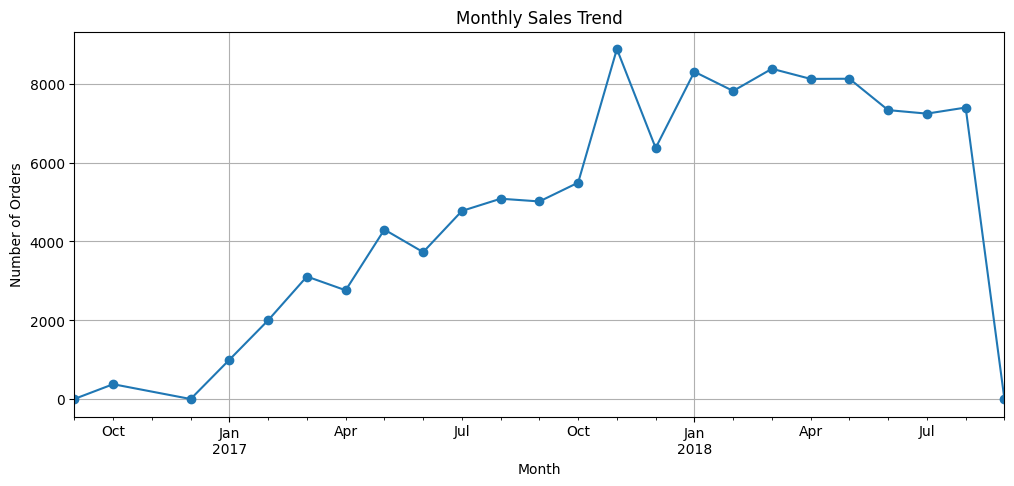

In [30]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

sales = df.groupby(
    df['order_purchase_timestamp'].dt.to_period('M')
).size()

plt.figure(figsize=(12,5))

sales.plot(marker='o')

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Number of Orders")

plt.grid(True)

plt.show()

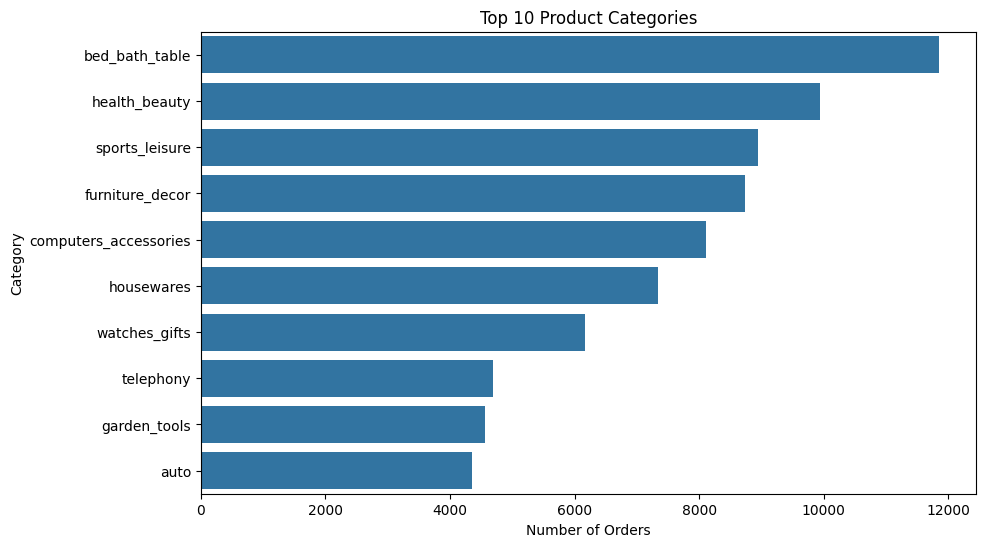

In [31]:
top = df['product_category_name_english'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top.values,
    y=top.index
)

plt.title("Top 10 Product Categories")

plt.xlabel("Number of Orders")

plt.ylabel("Category")

plt.show()

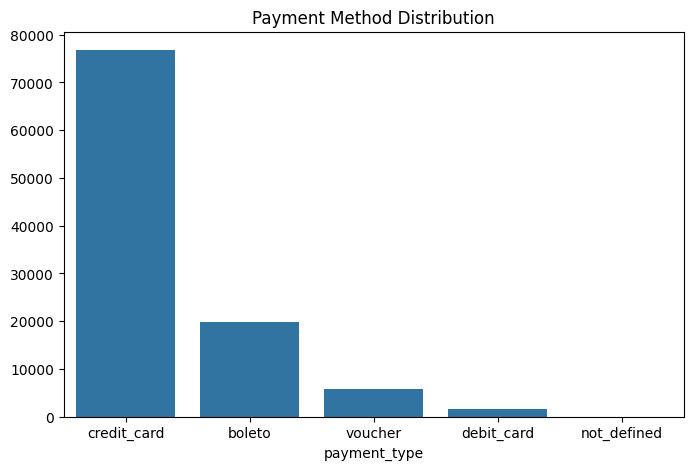

In [32]:
payment = payments['payment_type'].value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=payment.index,
    y=payment.values
)

plt.title("Payment Method Distribution")

plt.show()

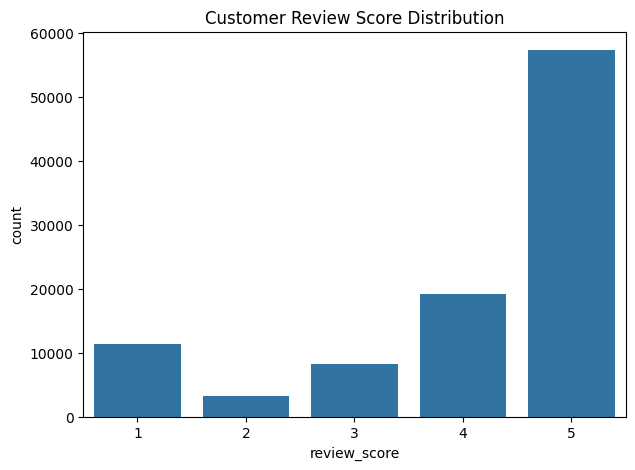

In [33]:
plt.figure(figsize=(7,5))

sns.countplot(
    x=reviews['review_score']
)

plt.title("Customer Review Score Distribution")

plt.show()

In [34]:
df['delivery_days'] = (
    pd.to_datetime(df['order_delivered_customer_date']) -
    pd.to_datetime(df['order_purchase_timestamp'])
).dt.days

avg_delivery = df['delivery_days'].mean()

print(f"Average Delivery Time : {avg_delivery:.2f} days")

Average Delivery Time : 11.98 days


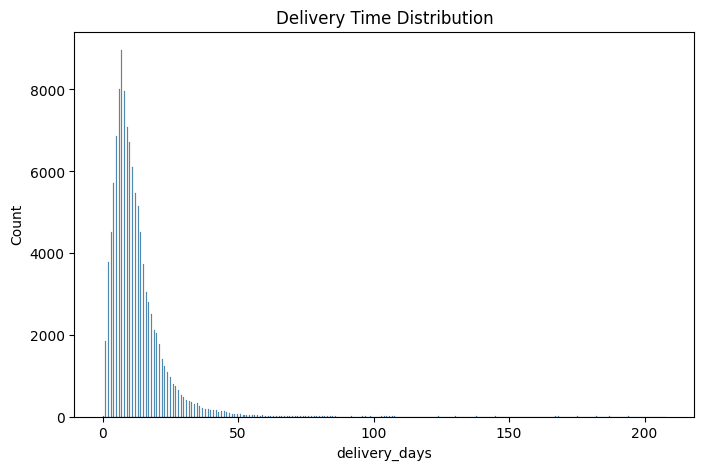

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(df['delivery_days'])

plt.title("Delivery Time Distribution")

plt.show()

In [36]:
df['estimated'] = pd.to_datetime(df['order_estimated_delivery_date'])

df['delivered'] = pd.to_datetime(df['order_delivered_customer_date'])

df['delay'] = (
    df['delivered']-
    df['estimated']
).dt.days

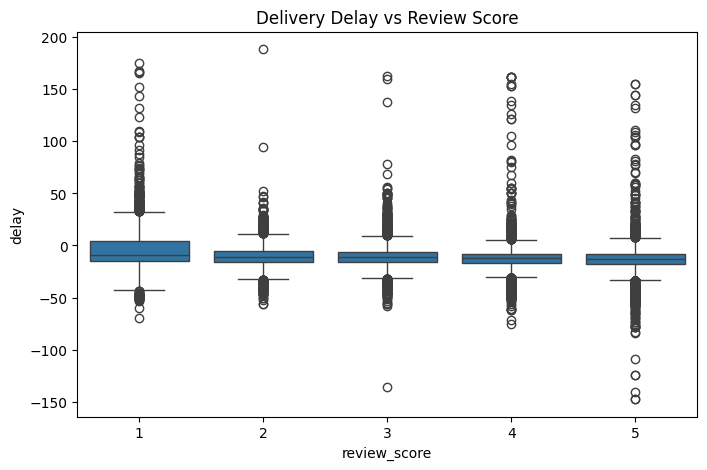

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='review_score',
    y='delay',
    data=df
)

plt.title("Delivery Delay vs Review Score")

plt.show()

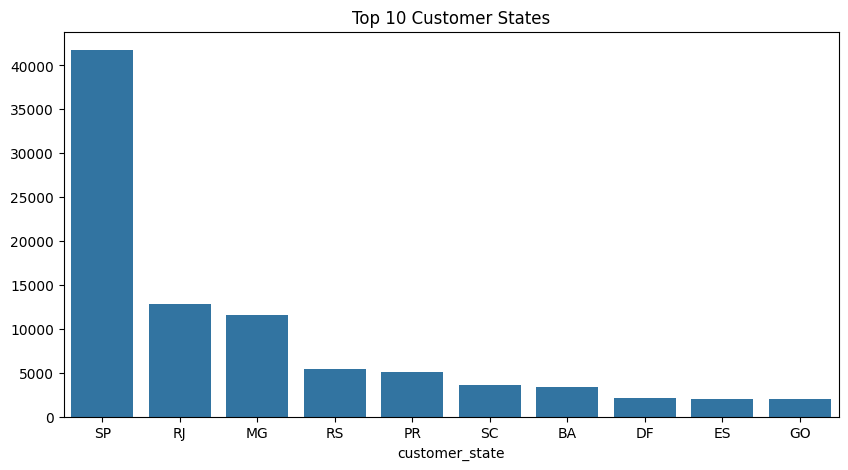

In [38]:
customer_state = customers['customer_state'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=customer_state.index,
    y=customer_state.values
)

plt.title("Top 10 Customer States")

plt.show()

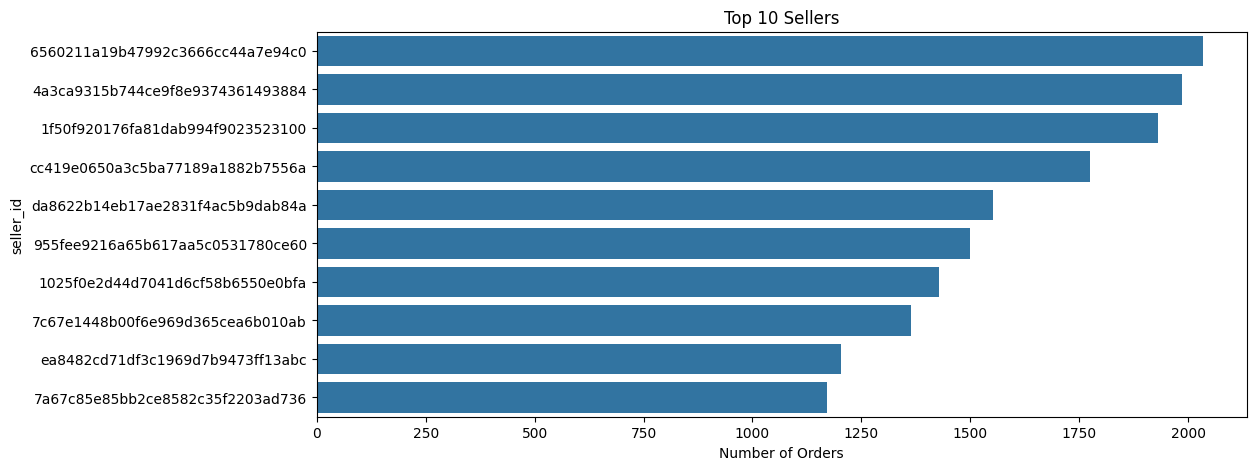

In [39]:
seller = (
    items.groupby("seller_id")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=seller.values,
    y=seller.index
)

plt.title("Top 10 Sellers")

plt.xlabel("Number of Orders")

plt.show()